## Why Poisson Arrivals Make the SNC Latency Bound Loose

In `method_v2`, the PPG is about 3× the measured p95 latency with Poisson arrivals, but only about 1.15× with periodic
arrivals. This notebook explains where that gap comes from, one step at a time.

To isolate the effect, everything here uses **one service** (s1 of `method_v2`) with its **true** parameters: no GP,
no epistemic uncertainty, no composition. Execution times are $X \sim \mathcal{N}(\mu, \sigma^2)$ with $\mu = 80$ ms,
$\sigma = 6$ ms, and items arrive at $\lambda = 3$/s, so the server is busy $\rho = \lambda\mu = 24\%$ of the time.
Only the arrival process changes between the two cases:

- **Poisson:** gaps between arrivals are exponential with mean $1/\lambda = 333$ ms.
- **Periodic:** gaps are $333$ ms $\pm$ up to 10% (uniform jitter).

The sections follow the chain of reasoning:

1. The two arrival processes: same rate, very different gaps
2. What the queue looks like over time
3. The true latency distribution
4. How the SNC bound is built, and which of its steps costs how much
5. The core reason: how large $\theta$ may be
6. What the bound pays for, term by term
7. How the looseness depends on $\varepsilon$ and on the load
8. Why it gets worse along a chain

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

mu, sigma = 0.080, 0.006      # execution time of s1 (s)
arrival_rate = 3.0            # lambda (items/s)
jitter = 0.1                  # relative half-width of the uniform jitter on periodic gaps
epsilon = 0.05                # violation probability (p95)

theta_grid = np.logspace(-1, 5, 4000)   # MGF parameter theta (1/s), same grid as method_v2
processes = ["poisson", "periodic"]
colors = {"poisson": "tab:red", "periodic": "tab:blue"}


def sample_gaps(process, shape, rng, rate=arrival_rate):
    if process == "poisson":
        return rng.exponential(1.0 / rate, shape)
    return (1.0 / rate) * (1 + rng.uniform(-jitter, jitter, shape))


def log_gap_mgf(process, rate=arrival_rate):
    # ln E[exp(-theta T)] of one gap T
    if process == "poisson":
        return np.log(rate / (rate + theta_grid))
    shortest, width = (1 - jitter) / rate, 2 * jitter / rate
    return -theta_grid * shortest + np.log(-np.expm1(-theta_grid * width)) - np.log(theta_grid * width)


def log_mgf_execution():
    # ln M_X(theta) = theta mu + theta^2 sigma^2 / 2
    return theta_grid * mu + 0.5 * theta_grid ** 2 * sigma ** 2


def simulate_latency(process, n_items, rng, rate=arrival_rate, warmup=1000):
    # Lindley recursion for one FIFO server: wait_i = max(0, wait_{i-1} + X_{i-1} - T_i)
    gaps = sample_gaps(process, n_items, rng, rate)
    execution = np.maximum(rng.normal(mu, sigma, n_items), 0.0)
    wait = np.zeros(n_items)
    for i in range(1, n_items):
        wait[i] = max(0.0, wait[i - 1] + execution[i - 1] - gaps[i])
    return (wait + execution)[warmup:], wait[warmup:]

## 1. Same Rate, Very Different Gaps

Both processes deliver 3 items per second on average. The difference is in how the gaps are spread. An item has to
wait whenever it arrives while the previous item is still being served, i.e. when its gap is shorter than about one
execution time ($\approx 80$ ms, dashed line).

The exponential distribution has its **highest density at zero**: short gaps are the most likely ones. Periodic gaps
never come anywhere near 80 ms.

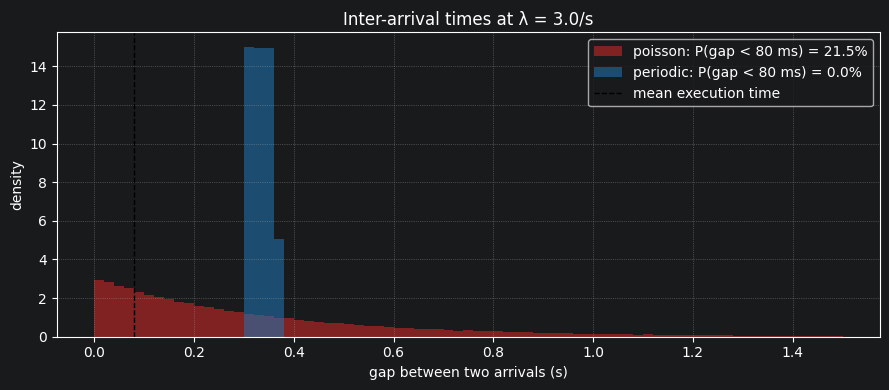

In [2]:
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1.5, 76)
for process in processes:
    gaps = sample_gaps(process, 200_000, rng)
    short = np.mean(gaps < mu)
    ax.hist(gaps, bins=bins, density=True, alpha=0.55, color=colors[process],
            label=f"{process}: P(gap < {mu * 1000:.0f} ms) = {short:.1%}")
ax.axvline(mu, color="black", linestyle="--", linewidth=1, label="mean execution time")
ax.set_xlabel("gap between two arrivals (s)")
ax.set_ylabel("density")
ax.set_title(f"Inter-arrival times at λ = {arrival_rate}/s")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 2. The Queue over Time

The plot shows the server's *backlog*: the work still to be done, in seconds. It jumps up by $X$ when an item arrives
and drains at slope $-1$. An item that arrives while the backlog is above zero has to wait.

With periodic arrivals, every item finds the server idle. With Poisson arrivals, items **bunch up**: two or three
arrive within a few tens of milliseconds, and the later ones wait behind the earlier ones. The server is still idle
76% of the time, so the average wait is small. But the p95 latency is decided by these bursts.

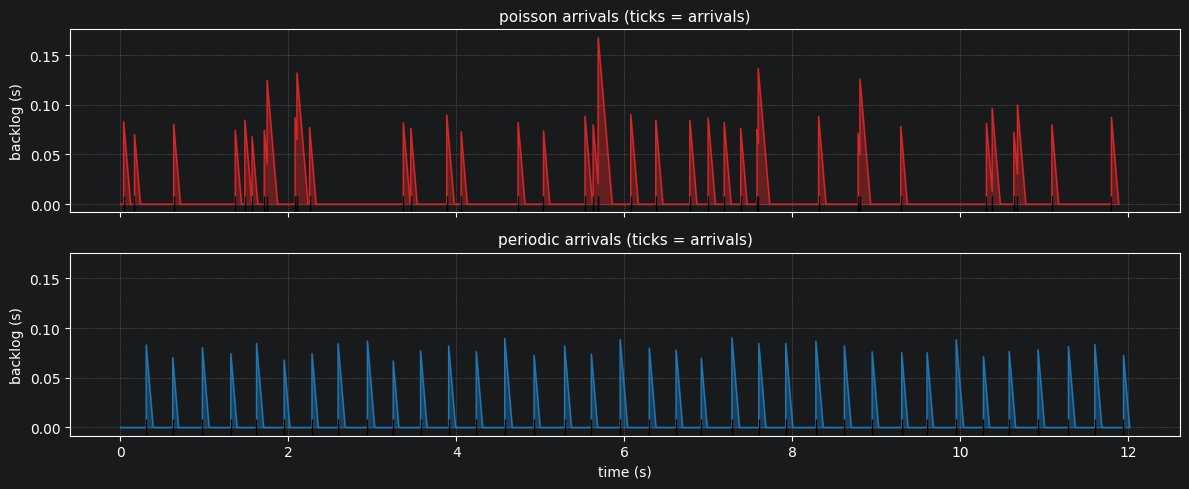

In [3]:
def backlog_path(arrivals, execution):
    # piecewise-linear backlog: jump by X at each arrival, drain at slope -1 down to 0
    times, levels, level, t = [0.0], [0.0], 0.0, 0.0
    for a, x in zip(arrivals, execution):
        drained = max(0.0, level - (a - t))
        if level > 0 and drained == 0.0:
            times.append(t + level); levels.append(0.0)
        times += [a, a]; levels += [drained, drained + x]
        level, t = drained + x, a
    times.append(t + level); levels.append(0.0)
    return np.array(times), np.array(levels)


horizon = 12.0
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, sharey=True)
for ax, process in zip(axes, processes):
    rng = np.random.default_rng(3)
    arrivals = np.cumsum(sample_gaps(process, 60, rng))
    arrivals = arrivals[arrivals < horizon]
    execution = rng.normal(mu, sigma, len(arrivals))
    times, levels = backlog_path(arrivals, execution)
    ax.fill_between(times, levels, color=colors[process], alpha=0.4, step=None)
    ax.plot(times, levels, color=colors[process], linewidth=1)
    ax.plot(arrivals, np.zeros_like(arrivals), "k|", markersize=12)
    ax.set_ylabel("backlog (s)")
    ax.set_title(f"{process} arrivals (ticks = arrivals)", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.6)
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

## 3. The True Latency Distribution

The latency (sojourn time) of an item is its wait plus its execution time. The plot shows the *complementary CDF*
$P(\text{latency} > d)$ on a log scale, which is the natural view for tails: the p95 is where a curve crosses
$10^{-1.3} = 0.05$.

- **Periodic:** latency is just the execution time. The tail is Gaussian, so it falls off a cliff just above 80 ms.
- **Poisson:** about three quarters of items don't wait, so the curve first drops to the share that waits. After
  that it falls along a **straight line**, i.e. the latency tail is **exponential**. The slope of that line is the
  tail's *decay rate*. Remember this slope; it's the key to everything below.

poisson   P(wait > 0) = 24.0%   mean latency = 92.7 ms   p95 latency = 155.6 ms
periodic  P(wait > 0) = 0.0%   mean latency = 80.0 ms   p95 latency = 89.9 ms


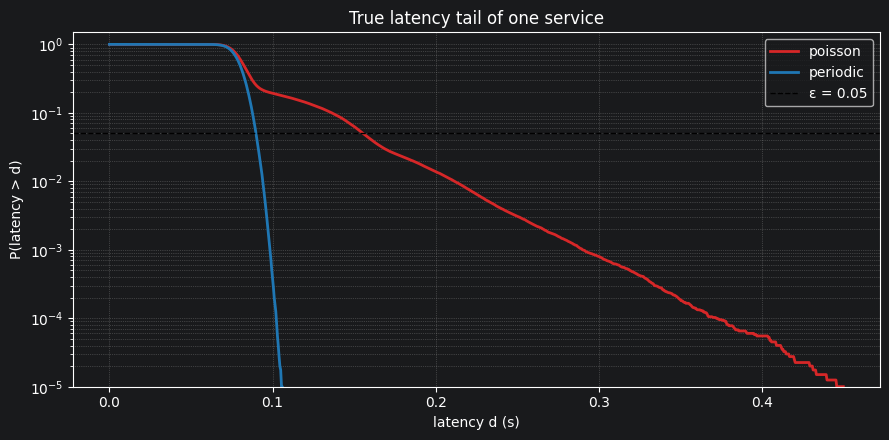

In [4]:
latency = {}
for process in processes:
    latency[process], wait = simulate_latency(process, 400_000, np.random.default_rng(1))
    print(f"{process:<9} P(wait > 0) = {np.mean(wait > 0):.1%}   mean latency = {latency[process].mean() * 1000:.1f} ms   "
          f"p95 latency = {np.quantile(latency[process], 1 - epsilon) * 1000:.1f} ms")

d_axis = np.linspace(0, 0.45, 901)
fig, ax = plt.subplots(figsize=(9, 4.5))
for process in processes:
    ccdf = 1 - np.searchsorted(np.sort(latency[process]), d_axis, side="right") / len(latency[process])
    ax.semilogy(d_axis, np.where(ccdf > 0, ccdf, np.nan), color=colors[process], linewidth=2, label=process)
ax.axhline(epsilon, color="black", linestyle="--", linewidth=1, label=f"ε = {epsilon}")
ax.set_ylim(1e-5, 1.5)
ax.set_xlabel("latency d (s)")
ax.set_ylabel("P(latency > d)")
ax.set_title("True latency tail of one service")
ax.legend()
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. How the Bound Is Built, and What Each Step Costs

The latency $W$ of an item is the largest backlog it can find when looking back over the items before it:

$$W = \max_{n \ge 0} D_n, \qquad D_n = \underbrace{X_0 + \dots + X_n}_{\text{work of the item and the } n \text{ before it}} \;-\; \underbrace{(T_1 + \dots + T_n)}_{\text{time the server had to do it}}.$$

$D_n$ is the latency the item would have if the server had been busy continuously since $n$ items back. The SNC bound
replaces the true tail $P(W > d)$ by something computable in two steps:

1. **Union bound over $n$:** $P(\max_n D_n > d) \le \sum_n P(D_n > d)$. Loose when several $D_n$ tend to be large together.
2. **Chernoff bound on each term with a common $\theta$:** $P(D_n > d) \le e^{-\theta d}\,\mathbb{E}[e^{\theta D_n}] = e^{-\theta d}\,M_X(\theta)\,\rho(\theta)^n$
   with $\rho(\theta) = M_X(\theta)\,\mathbb{E}[e^{-\theta T}]$. Summing the geometric series gives the bound from `method_v2`:
   $P(W > d) \le e^{-\theta d}\,M_X(\theta) / (1 - \rho(\theta))$, and the best $\theta$ is picked for every $d$.

Below, all three curves are computed for both processes: the truth, after step 1 (estimated by Monte Carlo), and after
step 2 (the SNC bound). The horizontal cut at $\varepsilon$ gives the p95 latency and the two bounds on it.

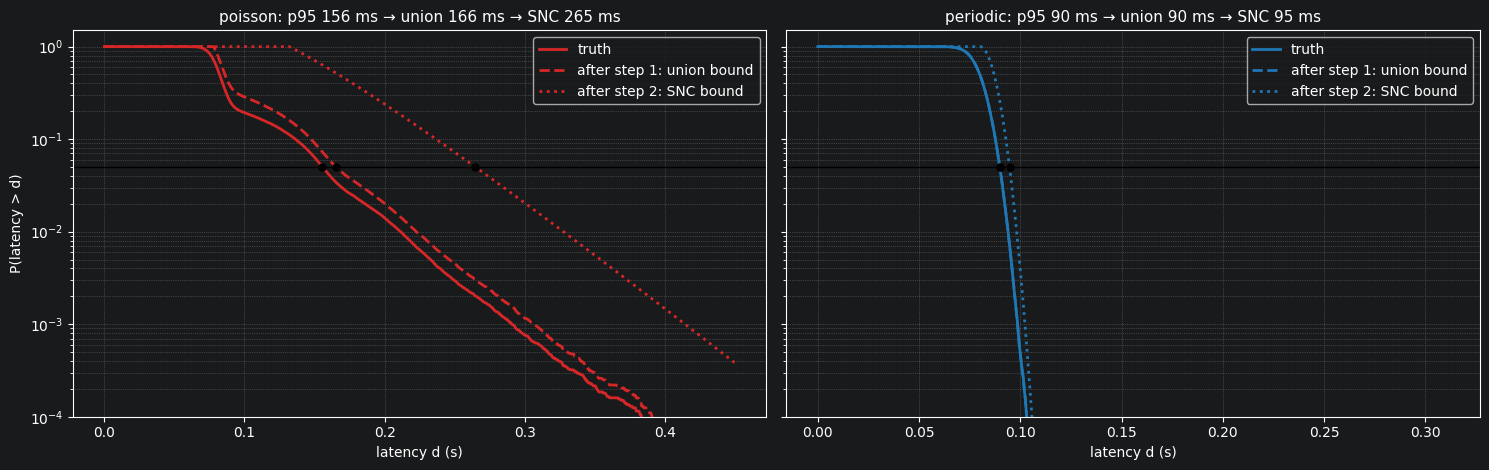

process    true p95  after union  after Chernoff  bound / true
poisson     155.7ms      165.5ms         264.8ms         1.70x
periodic     89.9ms       90.0ms          94.7ms         1.05x


In [5]:
n_paths, n_max = 200_000, 40


def log_latency_moment(process, rate=arrival_rate):
    # ln [ M_X(theta) / (1 - rho(theta)) ] on theta_grid; inf where rho(theta) >= 1
    log_mx = log_mgf_execution()
    log_rho = log_mx + log_gap_mgf(process, rate)
    moment = np.full_like(log_mx, np.inf)
    stable = log_rho < 0
    moment[stable] = log_mx[stable] - np.log1p(-np.exp(log_rho[stable]))
    return moment


def snc_bound(process, eps, rate=arrival_rate):
    values = (log_latency_moment(process, rate) - np.log(eps)) / theta_grid
    best = np.argmin(values)
    return values[best], theta_grid[best]


decomposition = {}
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
for ax, process in zip(axes, processes):
    rng = np.random.default_rng(2)
    X = rng.normal(mu, sigma, (n_paths, n_max + 1))
    T = sample_gaps(process, (n_paths, n_max), rng)
    D = np.cumsum(X, axis=1) - np.concatenate([np.zeros((n_paths, 1)), np.cumsum(T, axis=1)], axis=1)
    W = D.max(axis=1)

    true_ccdf = 1 - np.searchsorted(np.sort(W), d_axis, side="right") / n_paths
    D_sorted = np.sort(D, axis=0)
    union_ccdf = sum(1 - np.searchsorted(D_sorted[:, n], d_axis, side="right") / n_paths for n in range(n_max + 1))
    log_moment = log_latency_moment(process)
    snc_ccdf = np.exp(np.min(log_moment[None, :] - theta_grid[None, :] * d_axis[:, None], axis=1))

    true_q = np.quantile(W, 1 - epsilon)
    union_q = d_axis[np.argmax(union_ccdf <= epsilon)]
    snc_q, theta_opt = snc_bound(process, epsilon)
    decomposition[process] = {"true": true_q, "after union bound": union_q, "after Chernoff (SNC bound)": snc_q}

    for curve, label, style in [(true_ccdf, "truth", "-"), (union_ccdf, "after step 1: union bound", "--"),
                                (snc_ccdf, "after step 2: SNC bound", ":")]:
        ax.semilogy(d_axis, np.where(curve > 0, np.minimum(curve, 1), np.nan), style, color=colors[process], linewidth=2, label=label)
    ax.axhline(epsilon, color="black", linewidth=1)
    for q in (true_q, union_q, snc_q):
        ax.plot(q, epsilon, "ko", markersize=5)
    ax.set_ylim(1e-4, 1.5)
    ax.set_xlabel("latency d (s)")
    ax.set_title(f"{process}: p95 {true_q * 1000:.0f} ms → union {union_q * 1000:.0f} ms → SNC {snc_q * 1000:.0f} ms", fontsize=11)
    ax.legend(loc="upper right")
    ax.grid(True, which="both", linestyle=":", alpha=0.5)
axes[0].set_ylabel("P(latency > d)")
plt.tight_layout()
plt.show()

print(f"{'process':<9} {'true p95':>9} {'after union':>12} {'after Chernoff':>15} {'bound / true':>13}")
for process, row in decomposition.items():
    print(f"{process:<9} {row['true'] * 1000:>7.1f}ms {row['after union bound'] * 1000:>10.1f}ms "
          f"{row['after Chernoff (SNC bound)'] * 1000:>13.1f}ms {row['after Chernoff (SNC bound)'] / row['true']:>12.2f}x")

**What this shows.**
- **The union bound over $n$ costs almost nothing** for either process. The looseness is not about counting the
  queue lengths $n$ twice.
- **The Chernoff step is where the Poisson bound becomes loose.** On the log plot the SNC bound (dotted) runs roughly
  *parallel* to the true tail, but shifted to the right by about 100 ms. A constant shift of 100 ms on a p95 of about
  155 ms is a factor of about 1.7.
- For periodic arrivals the SNC bound is only a few milliseconds above the truth.

Why is the Poisson curve shifted by so much, and why is it parallel? That is the next section.

## 5. The Core Reason: How Large $\theta$ May Be

Solve the bound $P(W > d) \le e^{-\theta d} M_X(\theta)/(1 - \rho(\theta)) = \varepsilon$ for $d$:

$$d(\varepsilon) \;=\; \underbrace{\frac{\ln M_X(\theta)}{\theta}}_{\approx\,\mu \text{ (execution time)}} \;+\; \underbrace{\frac{-\ln(1 - \rho(\theta))}{\theta}}_{\text{queue}} \;+\; \underbrace{\frac{\ln(1/\varepsilon)}{\theta}}_{\text{confidence}}.$$

The last term is the price of the guarantee: it is **$\ln(1/\varepsilon) / \theta$ seconds**. At $\varepsilon = 0.05$ that is
$3.0/\theta$. With $\theta = 1000$/s it costs 3 ms; with $\theta = 25$/s it costs 120 ms. So the bound is tight only if
$\theta$ can be large.

But $\theta$ is capped: the bound only exists where the queue is stable in the MGF sense, $\rho(\theta) < 1$, i.e.

$$\underbrace{\ln M_X(\theta)}_{\text{work, grows like } \theta\mu} \;<\; \underbrace{-\ln \mathbb{E}[e^{-\theta T}]}_{\text{spacing of arrivals}}.$$

The right side is where the arrival process comes in:

- **Periodic:** $-\ln \mathbb{E}[e^{-\theta T}] \approx \theta \cdot 300$ ms grows **linearly** in $\theta$, with a slope far above
  $\mu = 80$ ms. The work never catches up until $\sigma^2$ matters, at $\theta$ in the thousands.
- **Poisson:** $-\ln \mathbb{E}[e^{-\theta T}] = \ln(1 + \theta/\lambda)$ grows only **logarithmically**, because very short gaps
  are likely (Section 1). The work $\theta\mu$ overtakes it already at $\theta^* \approx 30$/s.

$\theta^*$ is not an artefact of the bound: it is exactly the **decay rate of the true Poisson latency tail**, the
slope of the straight line in Section 3 (Cramér–Lundberg). A burst of arrivals is an event of probability
$\approx e^{-\theta^* d}$, and no exponential bound can decay faster than the thing it bounds.

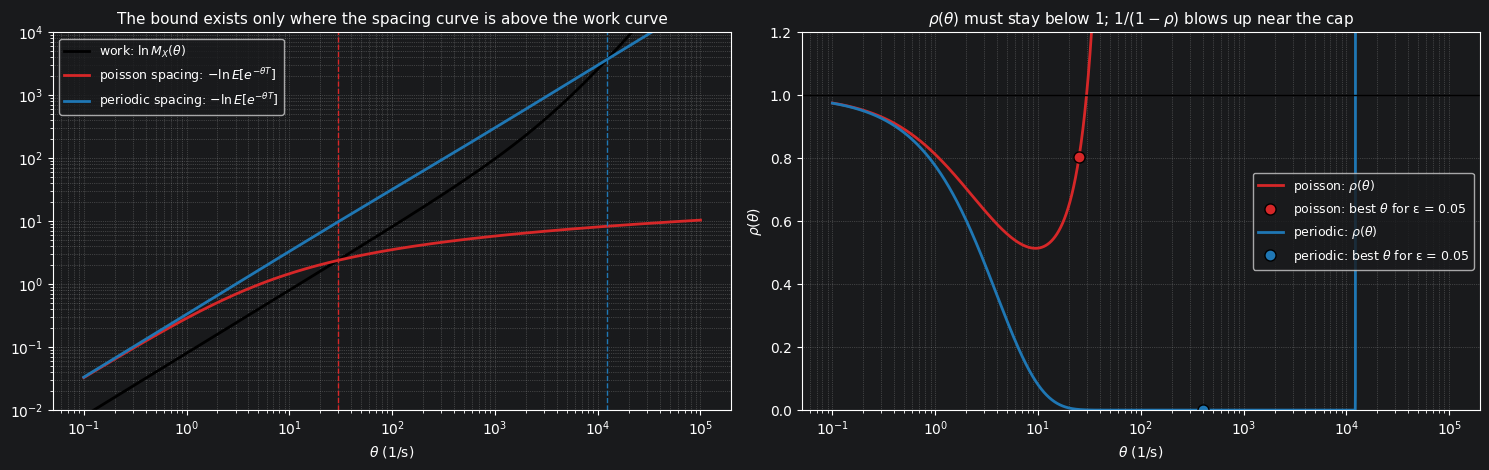

poisson   largest admissible theta =     29.7/s   best theta for ε = 0.05:    25.1/s
periodic  largest admissible theta =  12282.1/s   best theta for ε = 0.05:   407.3/s


In [6]:
fig, (ax_rate, ax_rho) = plt.subplots(1, 2, figsize=(15, 4.8))
log_mx = log_mgf_execution()
ax_rate.loglog(theta_grid, log_mx, color="black", linewidth=2, label=r"work: $\ln M_X(\theta)$")
theta_star = {}
for process in processes:
    spacing = -log_gap_mgf(process)
    ax_rate.loglog(theta_grid, spacing, color=colors[process], linewidth=2, label=rf"{process} spacing: $-\ln E[e^{{-\theta T}}]$")
    theta_star[process] = theta_grid[np.argmax(log_mx + log_gap_mgf(process) >= 0)]
    ax_rate.axvline(theta_star[process], color=colors[process], linestyle="--", linewidth=1)

    log_rho = log_mx + log_gap_mgf(process)
    ax_rho.semilogx(theta_grid, np.exp(np.minimum(log_rho, 1)), color=colors[process], linewidth=2, label=rf"{process}: $\rho(\theta)$")
    theta_opt = snc_bound(process, epsilon)[1]
    ax_rho.plot(theta_opt, np.exp(log_rho[np.searchsorted(theta_grid, theta_opt)]), "o",
                color=colors[process], markersize=8, markeredgecolor="black", label=rf"{process}: best $\theta$ for ε = {epsilon}")
ax_rate.set_xlabel(r"$\theta$ (1/s)")
ax_rate.set_title(r"The bound exists only where the spacing curve is above the work curve", fontsize=11)
ax_rate.set_ylim(1e-2, 1e4)
ax_rate.legend(fontsize=9)
ax_rate.grid(True, which="both", linestyle=":", alpha=0.5)

ax_rho.axhline(1, color="black", linewidth=1)
ax_rho.set_ylim(0, 1.2)
ax_rho.set_xlabel(r"$\theta$ (1/s)")
ax_rho.set_ylabel(r"$\rho(\theta)$")
ax_rho.set_title(r"$\rho(\theta)$ must stay below 1; $1/(1-\rho)$ blows up near the cap", fontsize=11)
ax_rho.legend(fontsize=9)
ax_rho.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

for process in processes:
    print(f"{process:<9} largest admissible theta = {theta_star[process]:>8.1f}/s   best theta for ε = {epsilon}: {snc_bound(process, epsilon)[1]:>7.1f}/s")

**Why the curves in Section 4 are parallel, and why the gap is still so large.** For Poisson, both the true tail and
the bound fall at (almost) the same rate $\theta^*$, so they are parallel lines on the log plot. The distance between
them is set by where each line *starts*:

- The true tail starts low: only about a quarter of the items wait at all, and most waits are short.
- The bound starts at $M_X(\theta)/(1-\rho(\theta)) \ge 1$: it does not know that most items don't wait. It
  effectively assumes every item is at the start of a burst.

Going from the bound's starting level down to $\varepsilon$ at slope $\theta^* \approx 30$/s takes about
$\ln(1/\varepsilon)/\theta^*$ plus the queue term, which is much longer than the true tail needs. The optimizer
can't fix this: pushing $\theta$ up to $\theta^*$ makes $1/(1-\rho)$ explode, pulling it down flattens the slope. It
settles at a compromise just below $\theta^*$.

With periodic arrivals the cap is in the thousands, the optimizer can pick a large $\theta$, and both the queue term
and the confidence term shrink to a few milliseconds. What is left is the Gaussian Chernoff bound
$\mu + \sigma\sqrt{2\ln(1/\varepsilon)}$, which is close to the true quantile $\mu + z_{1-\varepsilon}\sigma$ because $\sigma$ is small.

## 6. What the Bound Pays For

The three terms of $d(\varepsilon)$ at the optimal $\theta$, next to the true p95 split into the mean execution time
$\mu$ and everything above it. For Poisson, the part above $\mu$ is mostly waiting. For periodic, nobody waits, and it is
just the execution-time noise.

poisson   theta =   25.1/s | execution  80.5 ms + queue  64.8 ms + confidence ln(1/ε)/θ 119.5 ms = 264.8 ms   (true p95 155.7 ms)
periodic  theta =  407.3/s | execution  87.3 ms + queue   0.0 ms + confidence ln(1/ε)/θ   7.4 ms =  94.7 ms   (true p95  89.9 ms)


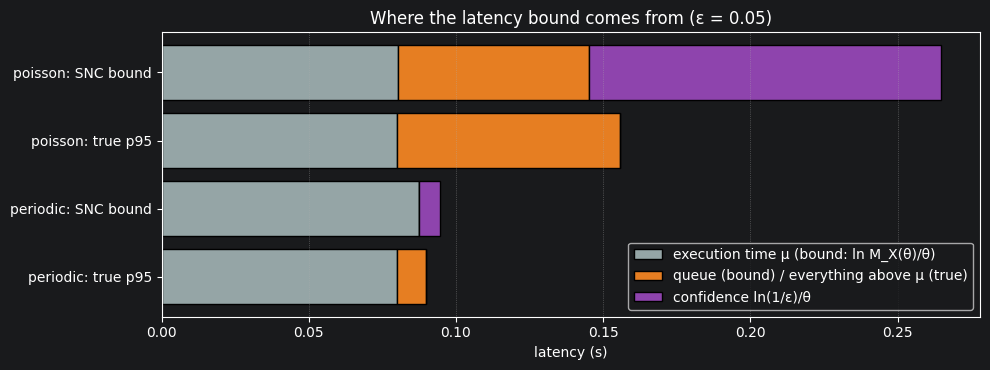

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.8))
rows = []
for process in processes:
    bound, theta_opt = snc_bound(process, epsilon)
    i = np.searchsorted(theta_grid, theta_opt)
    execution_term = log_mx[i] / theta_opt
    queue_term = (log_latency_moment(process)[i] - log_mx[i]) / theta_opt
    confidence_term = np.log(1 / epsilon) / theta_opt
    true_q = decomposition[process]["true"]
    rows.append((f"{process}: SNC bound", [execution_term, queue_term, confidence_term]))
    rows.append((f"{process}: true p95", [mu, true_q - mu, 0.0]))
    print(f"{process:<9} theta = {theta_opt:6.1f}/s | execution {execution_term * 1000:5.1f} ms + queue {queue_term * 1000:5.1f} ms "
          f"+ confidence ln(1/ε)/θ {confidence_term * 1000:5.1f} ms = {bound * 1000:5.1f} ms   (true p95 {true_q * 1000:5.1f} ms)")

labels = [label for label, _ in rows][::-1]
parts = np.array([values for _, values in rows])[::-1]
left = np.zeros(len(rows))
for k, (name, color) in enumerate(zip(["execution time μ (bound: ln M_X(θ)/θ)", "queue (bound) / everything above μ (true)", "confidence ln(1/ε)/θ"], ["#95a5a6", "#e67e22", "#8e44ad"])):
    ax.barh(labels, parts[:, k], left=left, color=color, edgecolor="black", label=name)
    left += parts[:, k]
ax.set_xlabel("latency (s)")
ax.set_title(f"Where the latency bound comes from (ε = {epsilon})")
ax.legend(loc="lower right")
ax.grid(True, axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

For Poisson, the bound's queue term alone is about as large as the whole wait an item actually sees at the p95, and
the confidence term comes on top. Both are divided by a small $\theta$ and therefore large. With periodic arrivals,
both are divided by a large $\theta$ and vanish.

## 7. Dependence on $\varepsilon$ and on the Load

- **$\varepsilon$:** for Poisson, the bound and the truth are parallel lines, so the gap is a roughly *constant*
  number of milliseconds. As $\varepsilon$ gets smaller, the latency itself grows and the *ratio* shrinks slowly.
  A 95% target is close to the worst case for an exponential bound.
- **Load:** the Poisson bound is loose at *every* load, even at 4% utilization where almost nobody waits. The
  cap $\theta^*$ rises as the load falls, but only slowly (about 60/s at $\lambda = 0.5$ vs. 30/s at $\lambda = 3$): as long as
  bursts are possible at all, the confidence term $\ln(1/\varepsilon)/\theta$ still costs tens of milliseconds. At high
  load, $\theta^*$ drops towards 0 and the queue term $-\ln(1-\rho(\theta))/\theta$ grows, so the ratio climbs.
  Periodic arrivals stay flat: the gaps stay longer than one execution time up to the highest load shown.

poisson   bound ÷ true by ε:    1e-01: 1.74x  3e-02: 1.69x  1e-02: 1.55x  3e-03: 1.50x  1e-03: 1.44x  3e-04: 1.41x  1e-04: 1.37x  3e-05: 1.35x  1e-05: 1.32x
poisson   bound ÷ true by load: ρ=0.04: 1.70x  ρ=0.08: 1.60x  ρ=0.16: 1.56x  ρ=0.24: 1.70x  ρ=0.32: 1.82x  ρ=0.48: 2.03x  ρ=0.64: 2.31x  ρ=0.80: 2.77x
periodic  bound ÷ true by ε:    1e-01: 1.06x  3e-02: 1.05x  1e-02: 1.05x  3e-03: 1.04x  1e-03: 1.04x  3e-04: 1.04x  1e-04: 1.03x  3e-05: 1.03x  1e-05: 1.03x
periodic  bound ÷ true by load: ρ=0.04: 1.05x  ρ=0.08: 1.05x  ρ=0.16: 1.05x  ρ=0.24: 1.05x  ρ=0.32: 1.05x  ρ=0.48: 1.05x  ρ=0.64: 1.05x  ρ=0.80: 1.05x


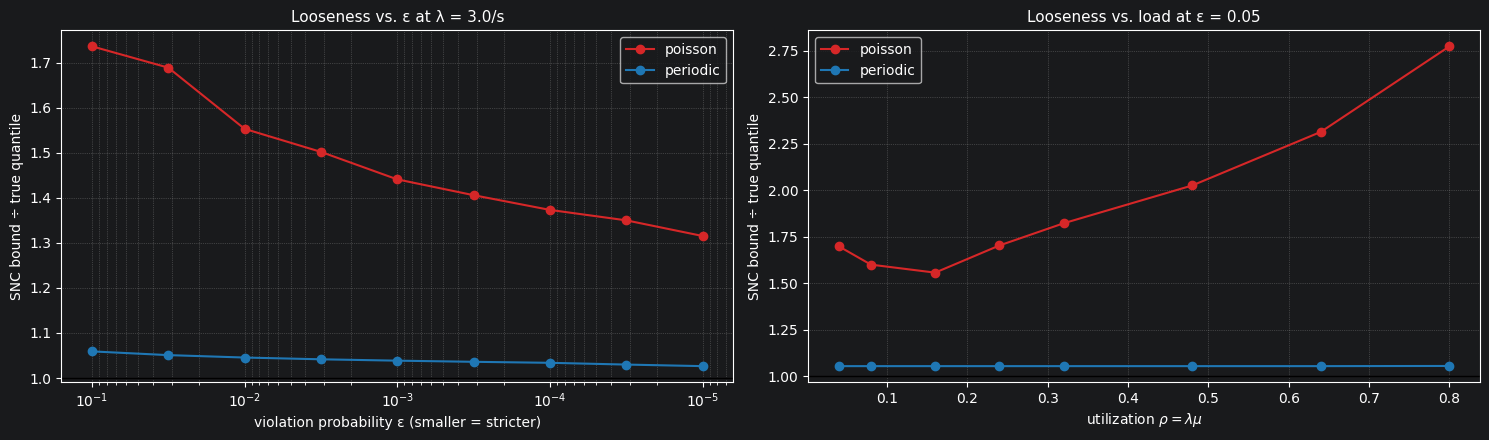

In [8]:
epsilons = np.logspace(-1, -5, 9)
rates = np.array([0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0])

fig, (ax_eps, ax_load) = plt.subplots(1, 2, figsize=(15, 4.5))
for process in processes:
    samples, _ = simulate_latency(process, 2_000_000, np.random.default_rng(4))
    ratios = [snc_bound(process, eps)[0] / np.quantile(samples, 1 - eps) for eps in epsilons]
    ax_eps.semilogx(epsilons, ratios, "o-", color=colors[process], label=process)
    print(f"{process:<9} bound ÷ true by ε:    " + "  ".join(f"{eps:.0e}: {r:.2f}x" for eps, r in zip(epsilons, ratios)))

    ratios = []
    for rate in rates:
        samples, _ = simulate_latency(process, 400_000, np.random.default_rng(5), rate=rate)
        ratios.append(snc_bound(process, epsilon, rate)[0] / np.quantile(samples, 1 - epsilon))
    ax_load.plot(rates * mu, ratios, "o-", color=colors[process], label=process)
    print(f"{process:<9} bound ÷ true by load: " + "  ".join(f"ρ={rate * mu:.2f}: {r:.2f}x" for rate, r in zip(rates, ratios)))

ax_eps.invert_xaxis()
ax_eps.set_xlabel("violation probability ε (smaller = stricter)")
ax_eps.set_title(f"Looseness vs. ε at λ = {arrival_rate}/s", fontsize=11)
ax_load.set_xlabel(r"utilization $\rho = \lambda\mu$")
ax_load.set_title(f"Looseness vs. load at ε = {epsilon}", fontsize=11)
for ax in (ax_eps, ax_load):
    ax.axhline(1, color="black", linewidth=1)
    ax.set_ylabel("SNC bound ÷ true quantile")
    ax.legend()
    ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Why It Gets Worse Along a Chain

In `method_v2`, every node bound assumes the *external* arrival process. For the first service that's correct. For
the second, it's not: s2 receives s1's **departures**, and s1 can't release two items closer together than one
execution time ($\approx 80$ ms). The bursts of the Poisson input are smoothed out by s1. Since s2 (72 ms) is faster
than that, it almost never queues.

The node bound for s2 still assumes Poisson arrivals, so it pays the whole Section 5 penalty a second time, for a
queue that doesn't exist. The same happens at every further node, which is why the PPG's looseness grows with the
chain depth in `method_v2` Section 9. With periodic arrivals there is nothing to smooth and nothing to over-count.

In [9]:
mu_2, sigma_2 = 0.072, 0.001   # s2 of method_v2
rng = np.random.default_rng(6)
n_items = 400_000
arrivals = np.cumsum(sample_gaps("poisson", n_items, rng))


def fifo(entering, execution):
    leaving = np.empty_like(entering)
    previous = 0.0
    for i in range(len(entering)):
        previous = max(entering[i], previous) + execution[i]
        leaving[i] = previous
    return leaving


s1_leaving = fifo(arrivals, np.maximum(rng.normal(mu, sigma, n_items), 0))
s2_in_chain = fifo(s1_leaving, np.maximum(rng.normal(mu_2, sigma_2, n_items), 0)) - s1_leaving
s2_poisson_fed = fifo(arrivals, np.maximum(rng.normal(mu_2, sigma_2, n_items), 0)) - arrivals

gaps_into_s2 = np.diff(s1_leaving)
print(f"shortest gap into s2 (1st percentile): {np.quantile(gaps_into_s2, 0.01) * 1000:.0f} ms  (Poisson: {np.quantile(np.diff(arrivals), 0.01) * 1000:.0f} ms)")
print(f"s2 p95 latency behind s1 (real):        {np.quantile(s2_in_chain, 1 - epsilon) * 1000:.1f} ms")
print(f"s2 p95 latency if fed Poisson (assumed): {np.quantile(s2_poisson_fed, 1 - epsilon) * 1000:.1f} ms")

shortest gap into s2 (1st percentile): 70 ms  (Poisson: 3 ms)
s2 p95 latency behind s1 (real):        73.8 ms
s2 p95 latency if fed Poisson (assumed): 135.9 ms


## Summary

- **Poisson arrivals come in bursts.** Short gaps are the most likely gaps, so a few items regularly arrive almost
  together. That makes the true latency tail *exponential* with a slow decay rate $\theta^*$ (about 30/s here).
- **An SNC bound can use $\theta$ only up to that decay rate**, because $\rho(\theta)$ must stay below 1. The bound pays
  $\ln(1/\varepsilon)/\theta$ seconds for its confidence and $-\ln(1-\rho(\theta))/\theta$ for the queue. With $\theta \le 30$/s
  those are each tens of milliseconds or more.
- **The bound doesn't know that most items don't wait.** It runs parallel to the true tail but starts from
  probability 1 instead of the share of items that wait. That shift, about 100 ms here, is the looseness. The union bound
  over queue lengths is not the problem.
- **Periodic arrivals** don't limit $\theta$, so the queue and confidence terms vanish and the bound is essentially the
  Gaussian bound on the execution time.
- **In a chain**, every node bound pays the penalty again, even though only the first node sees bursty arrivals.

**Levers, if the bound has to be tighter under Poisson arrivals:**
- Account for the idle share. Martingale-based SNC bounds carry a prefactor below 1 that reflects that most
  items don't wait, and they are much tighter for exactly this reason.
- Use network service curves for the chain, so the burst is paid only once rather than once per node.
- Report stricter targets (e.g. $\varepsilon = 10^{-3}$), where the constant gap is a smaller share of the latency.